In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os 



In [2]:
df = pd.read_csv('wnccastats.csv')


In [3]:
df.columns = ["team", "seed", "off_reb", "def_reb", "turnovers", "ft", "fg"]
df.head().T 


,0,1,2,3
team,UVA,TCU,South Carolina,Oklahoma
seed,10,3,1,1
off_reb,0.381,0.324,0.392,0.391
def_reb,0.729,0.748,0.703,0.735
turnovers,0.165,0.168,0.146,0.167
ft,0.714,0.767,0.724,0.722
fg,0.442,0.47,0.509,0.451


Create Game Match-ups that are the path for UVA to get to the final four 

In [4]:
df = df.set_index("team")

In [5]:
print(df.index.tolist())

['UVA', 'TCU', 'South Carolina', 'Oklahoma ']


In [6]:
uva = df.loc["UVA"]
tcu = df.loc["TCU"]
sc = df.loc["South Carolina"]
ok = df.loc["Oklahoma "] 

## Calculate the probability of UVA beating TCU, South Carolina, and Oklahoma. 

In [7]:
def get_matchup(team_a, team_b):
    return {
        "seed_diff": team_a["seed"] - team_b["seed"],
        "off_reb_diff": team_a["off_reb"] - team_b["off_reb"],
        "def_reb_diff": team_a["def_reb"] - team_b["def_reb"],
        "turnover_diff": -(team_a["turnovers"] - team_b["turnovers"]),
        "ft_diff": team_a["ft"] - team_b["ft"],
        "fg_diff": team_a["fg"] - team_b["fg"]
    }

In [8]:
def get_score(matchup):
    return (
        -0.2 * matchup["seed_diff"] +
         0.3 * matchup["off_reb_diff"] +
         0.2 * matchup["def_reb_diff"] +
         0.3 * matchup["turnover_diff"] +
         0.2 * matchup["ft_diff"] +
         0.2 * matchup["fg_diff"]
    )

In [9]:
def get_prob(score):
    return 1 / (1 + np.exp(-score)) 

In [10]:
p_uva_tcu = get_prob(get_score(get_matchup(uva, tcu)))
p_uva_sc = get_prob(get_score(get_matchup(uva, sc)))
p_uva_ok = get_prob(get_score(get_matchup(uva, ok)))

In [11]:
print(p_uva_tcu)
print(p_uva_sc)
print(p_uva_ok)

0.19749893344431405
0.1395298943085911
0.14100109390264445


## Calculate the Probability South Carolina beats Oklahoma, or Oklahoma beats South Carolina.

In [12]:
matchup_sc_ok = (
    -0.2 * (sc["seed"] - ok["seed"]) + 
    0.3 * (sc["off_reb"] - ok["off_reb"]) + 
    0.2 * (sc["def_reb"] - ok["def_reb"]) + 
    0.3 * -(sc["turnovers"] - ok["turnovers"]) +    
    0.2 * (sc["ft"] - ok["ft"]) + 
    0.2 * (sc["fg"] - ok["fg"])                     
)

p_sc_ok = get_prob(matchup_sc_ok)
print(p_sc_ok)

0.5030499621703964


In [13]:
p_ok_sc = 1 - p_sc_ok
print(p_ok_sc)

0.49695003782960356


## Final Four - Probability UVA making it.  

In [14]:
prob_final_four = p_uva_tcu * (p_sc_ok * p_uva_sc + p_ok_sc * p_uva_ok)
print(prob_final_four)

0.02770139928682135


Visual for Predicitons 

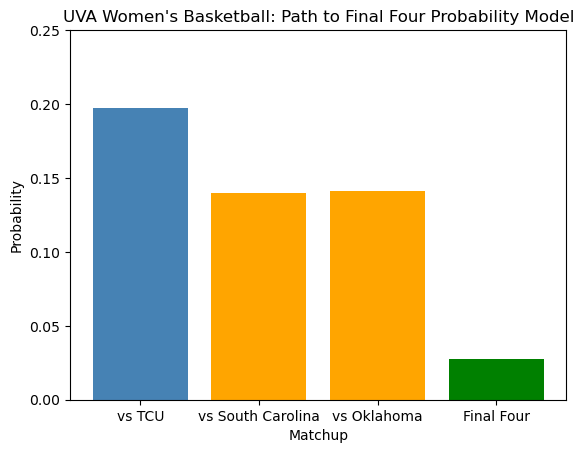

In [18]:
labels = [
    "vs TCU",
    "vs South Carolina",
    "vs Oklahoma",  
    "Final Four"        
]

values = [
    p_uva_tcu,
    p_uva_sc,
    p_uva_ok,
    prob_final_four
]

colors = [
    "steelblue", # vs TCU
    "orange",   # elite 8
    "orange",   # elite 8
    "green",   # Final Four
]

plt.figure()
plt.bar(labels, values, color=colors)

plt.title("UVA Women's Basketball: Path to Final Four Probability Model")
plt.ylabel("Probability")
plt.xlabel("Matchup")

plt.ylim(0, 0.25)

plt.show()
